In [14]:
import numpy as np
import matplotlib.pyplot as plt

L'algoritmo di Verlet permette di simulare la dinamica molecolare di un sistema. Esso implementa la seguente regola di evoluzione per le posizioni delle particelle del sistema al tempo $t$:


$$
\mathbf{r}(t+\Delta t)
= 2\,\mathbf{r}(t)
- \mathbf{r}(t-\Delta t)
+ \mathbf{F}(t)\,\Delta t^{2}.
$$




dove $\Delta t$ è un intervallo di tempo, che viene fornito come parametro all'algoritmo.

I termini dal quarto ordine in poi in $\Delta t$ vengono trascurati. Si mostra che l'algoritmo ha buone proprietà di conservazione dell'energia ed è manifestamente reversibile.

Solitamente, vengono applicate ulteriori semplificazioni:

* **Condizioni periodiche al contorno:** si considera la cella, solitamente cubica di lato $L$, contenente le particelle simulate (il cui numero è soggetto a limitazioni tecniche) replicata all'infinito. Ogni particella avrà dunque infinite *immagini* nelle altre celle. In questo modo si può studiare il *bulk* del sistema, trascurando le molecole in superficie, che risentono di forze molto diverse e la cui trattazione è complicata. Questo schema impedisce la formazione di fluttuazioni a lunga lunghezza d'onda (rendendo delicate le simulazioni vicino ai punti critici) e necessita di ulteriori considerazioni per potenziali a lungo range.

* **Minimum image convention:** data una particella, si considera una "scatola" centrata in essa con le stesse dimensioni della cella di base. Solo le particelle (o le loro immagini) i cui centri cadono dentro la "scatola" vengono considerate nel calcolo delle forze a cui è soggetta la particella in esame. In pratica, la si considera interagire solo con l'immagine ad essa più vicina di ciascuna altra particella.

* **Cut-off sferico:** per forze a breve range, si considera una sfera di raggio $r_c$, oltre la quale il potenziale viene posto artificialmente a $0$. Ciò permette di ridurre il costo computazionale, ma introduce un errore dovuto al troncamento del potenziale. Solitamente è possibile correggere parzialmente questo errore tramite il calcolo delle correzioni di coda, che verrà affrontato nella lezione 7.


# Esercizio 4.1

Si considera un sistema soggetto al potenziale di Lennard-Jones. Si utilizzano le unità ridotte (o naturali), definite a partire dai parametri del sistema: $\epsilon$ (profondità della buca di potenziale), $\sigma$ (posizione del minimo) e $m$ (massa delle particelle).

Tramite una simulazione con l'algoritmo di Verlet, si vuole costruire un istogramma della distribuzione delle velocità, per poi confrontarlo con la distribuzione di Maxwell-Boltzmann, espressa in unità naturali.

Per costruire l'istogramma della distribuzione delle velocità, si scorre ogni particella del sistema. Per ciascuna particella viene calcolato il modulo della velocità. 
Si verifica quindi che la velocità sia inferiore al limite massimo considerato, pari a $N_{\mathrm{bins}},\Delta v$. Se questa condizione è soddisfatta, si determina il bin dell'istogramma a cui appartiene la velocità tramite

$$
\mathrm{bin} = \left\lfloor \frac{v}{\Delta v} \right\rfloor,
$$

dove $\Delta v$ è l'ampiezza di ciascun bin.

Ripetendo questa procedura per tutte le particelle e per tutti gli step della simulazione, si ottiene l'istogramma della distribuzione dei moduli delle velocità.


La simulazione viene eseguita con i seguenti parametri:

1. **Numero di blocchi:** $N_{\mathrm{BLOCKS}} = 10$
2. **Numero di step per blocco:** $N_{\mathrm{STEPS}} = 1000$
3. **Temperatura iniziale:** $T = 1.8$
4. **Numero di particelle:** $N_{\mathrm{PART}} = 108$
5. **Densità:** $\rho = 0.8$
6. **Raggio di cut-off:** $r_{\mathrm{cut}} = 2.5$
7. **Parametro $\Delta$ dell'algoritmo di Verlet:** $\Delta = 0.001$
8. **Numero di bins:** $N_{\mathrm{BINS}} = 30$

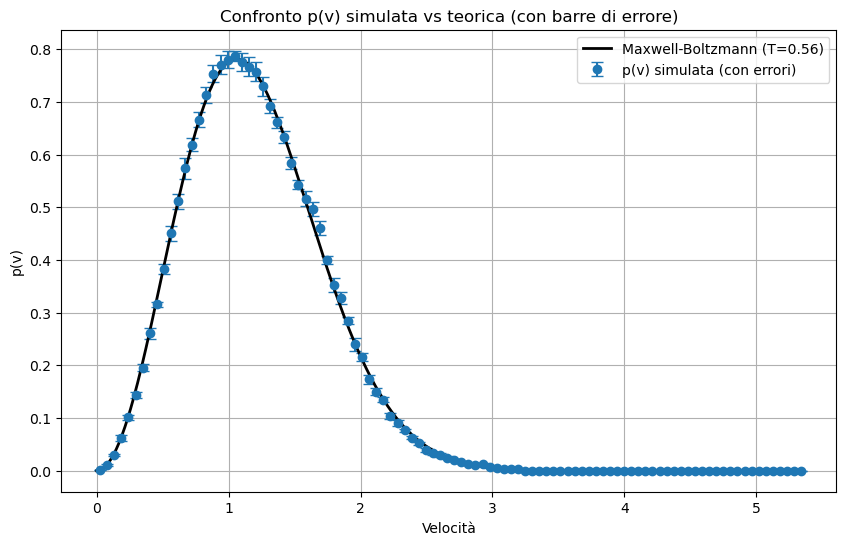

In [17]:
data = np.loadtxt("sim_num_es04.1/OUTPUT/pofv.dat")

nbins = 100
nblocks = len(data) // nbins

sim_block = data[(nblocks-1)*nbins : nblocks*nbins]

v = sim_block[:, 0]
p_sim = sim_block[:, 2]      # cumulative_average
err_sim = sim_block[:, 3]    # error

temp = np.loadtxt("sim_num_es04.1/OUTPUT/temperature.dat")
T = temp[:, 2].mean()

def maxwell_boltzmann(v, T):
    return v**2 * np.exp(-v**2/(2*T))

v_theory = np.linspace(0, v.max(), 500)
p_theory = maxwell_boltzmann(v_theory, T)

area_sim = np.trapz(p_sim, v)
area_theory = np.trapz(p_theory, v_theory)
p_theory *= area_sim / area_theory

plt.figure(figsize=(10,6))

plt.errorbar(v, p_sim, yerr=err_sim, fmt='o', capsize=4,
             label="p(v) simulata")

plt.plot(v_theory, p_theory, 'k-', lw=2,
         label=f"Maxwell-Boltzmann (T={T:.2f})")

plt.xlabel("Velocità")
plt.ylabel("p(v)")
plt.title("Confronto p(v) simulata vs teorica")
plt.grid(True)
plt.legend()
plt.show()


## Commento
Si osserva che la distribuzione delle velocità approssima bene la distribuzione di Maxwell-Boltzmann.

# Esercizio 4.2

Il sistema viene inizializzato in una condizione a bassa entropia, con una configurazione FCC in cui le particelle occupano solamente metà della box. Questa configurazione si ottiene sostituendo `_side` con `_halfside` nell'inizializzazione del sistema.

Le velocità iniziali hanno modulo

$$
v^* = \sqrt{3T^*}
$$

e vengono assegnate scegliendo uniformemente tra le sei direzioni possibili: $\pm x$, $\pm y$ e $\pm z$.


La simulazione viene eseguita con i seguenti parametri:

1. **Numero di blocchi:** $N_{\mathrm{BLOCKS}} = 400$
2. **Numero di step per blocco:** $N_{\mathrm{STEPS}} = 100$
3. **Temperatura iniziale:** $T = 2$
4. **Numero di particelle:** $N_{\mathrm{PART}} = 108$
5. **Densità:** $\rho = 0.05$
6. **Raggio di cut-off:** $r_{\mathrm{cut}} = 5.0$
7. **Parametro $\Delta$ dell'algoritmo di Verlet:** $\Delta = 0.001$
8. **Numero di bins:** $N_{\mathrm{BINS}} = 30$


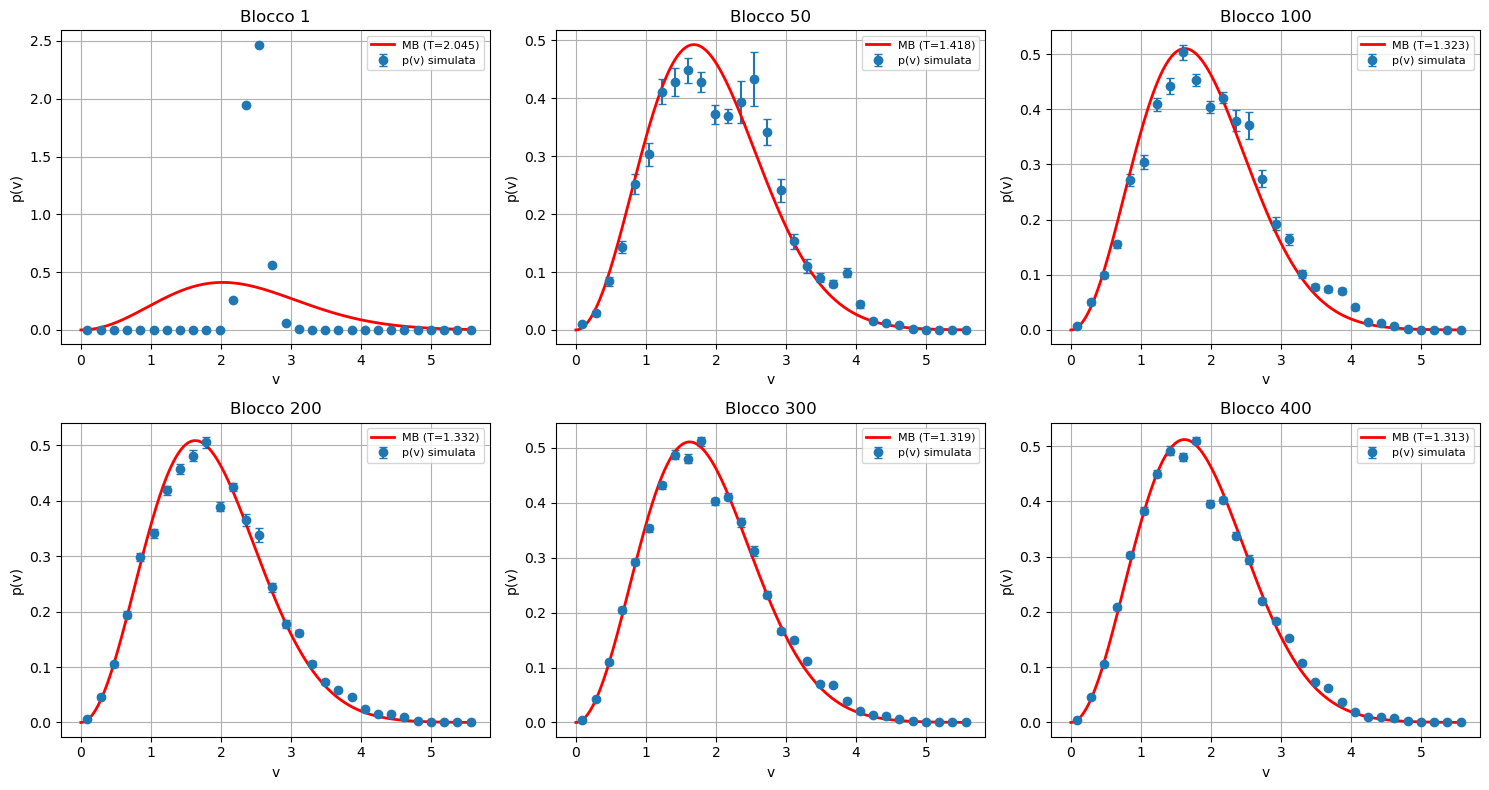

In [24]:
data = np.genfromtxt("sim_num_es04.2/OUTPUT/pofv.dat", comments="#")

nbins = 30
nblocks = len(data) // nbins

blocks_to_plot = [1, 50, 100, 200, 300, nblocks]

temp = np.genfromtxt("sim_num_es04.2/OUTPUT/temperature.dat", comments="#")

def maxwell_boltzmann(v, T):
    return v**2 * np.exp(-v**2/(2*T))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, b in enumerate(blocks_to_plot):
    ax = axes[i]

    start = (b-1) * nbins
    end   = b * nbins
    block = data[start:end]

    if block.size == 0:
        ax.text(0.5, 0.5, f"Blocco {b} vuoto",
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"Blocco {b}")
        continue

    v = block[:, 0]
    p_sim = block[:, 2]
    err_sim = block[:, 3]

    T_block = temp[b-1, 1]   # ACTUAL_T

    v_theory = np.linspace(0, v.max(), 500)
    p_theory = maxwell_boltzmann(v_theory, T_block)

    area_sim = np.trapz(p_sim, v)
    area_theory = np.trapz(p_theory, v_theory)
    p_theory *= area_sim / area_theory

    ax.errorbar(v, p_sim, yerr=err_sim, fmt='o', capsize=3,
                label=f"p(v) simulata")
    ax.plot(v_theory, p_theory, 'r-', lw=2,
            label=f"MB (T={T_block:.3f})")

    ax.set_title(f"Blocco {b}")
    ax.set_xlabel("v")
    ax.set_ylabel("p(v)")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Commento
Si osserva come la distribuzione delle velocità, che al blocco 1 è inizialmente molto simile a una delta di Dirac, evolva progressivamente verso una distribuzione di Maxwell-Boltzmann. Si osserva inoltre una diminuzione della temperatura nel corso della simulazione.

Questo comportamento può essere spiegato considerando che, inizialmente, le particelle si trovano molto vicine tra loro, all’interno della regione attrattiva del potenziale di Lennard-Jones. Durante l’evoluzione del sistema, le particelle tendono a disperdersi verso configurazioni caratterizzate da una maggiore entropia, determinando un aumento dell’energia potenziale. Per la conservazione dell’energia totale, tale aumento deve essere compensato da una diminuzione dell’energia cinetica e, di conseguenza, della temperatura del sistema.


# Esercizio 4.3

Con lo stesso sistema dell'esercizio 4.2, si esegue una simulazione con $N = 50$  blocchi e $M=100$ step per blocco. Dopodichè, partendo dalla configurazione finale, si inverte il tempo e si esegue una nuova simulazione.

Per invertire il tempo è sufficiente inizializzare la velocità delle particelle della nuova simulazione con la velocità finale a segno invertito.

## Time Forward

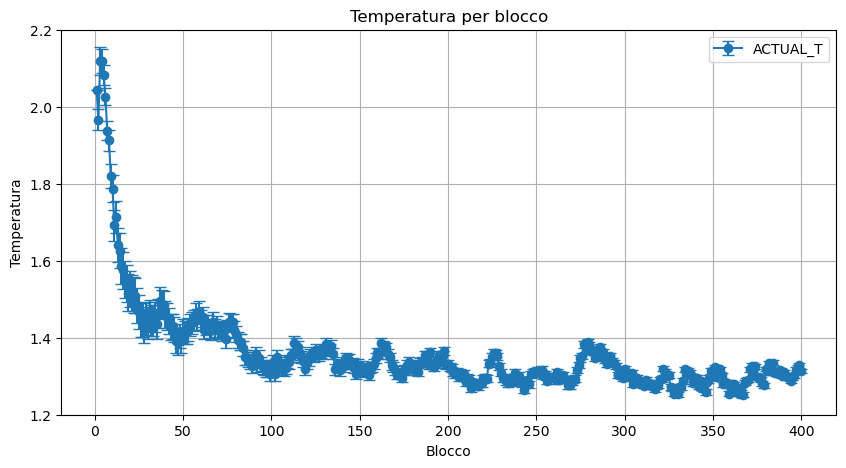

In [3]:
import numpy as np
import matplotlib.pyplot as plt

temp = np.genfromtxt("sim_num_es04.2/OUTPUT/temperature.dat", comments="#")

blocks = temp[:, 0]
actual_T = temp[:, 1]
T_ave = temp[:, 2]
err_T = temp[:, 3]

plt.figure(figsize=(10,5))
plt.errorbar(blocks, actual_T, yerr=err_T, fmt='o-', capsize=4, label="ACTUAL_T")

plt.xlabel("Blocco")
plt.ylabel("Temperatura")
plt.title("Temperatura per blocco")
plt.grid(True)
plt.legend()
plt.show()


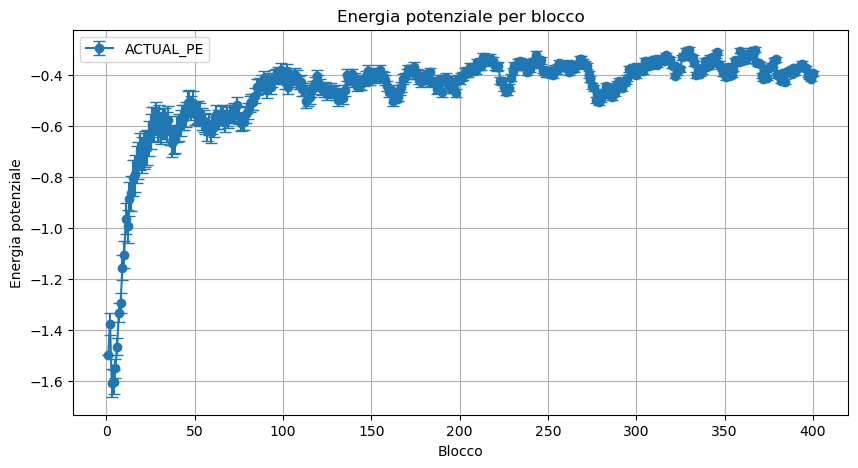

In [2]:
import numpy as np
import matplotlib.pyplot as plt

pe = np.genfromtxt("sim_num_es04.2/OUTPUT/potential_energy.dat", comments="#")

blocks = pe[:, 0]
actual_PE = pe[:, 1]
PE_ave = pe[:, 2]
err_PE = pe[:, 3]

plt.figure(figsize=(10,5))
plt.errorbar(blocks, actual_PE, yerr=err_PE, fmt='o-', capsize=4, label="ACTUAL_PE")

plt.xlabel("Blocco")
plt.ylabel("Energia potenziale")
plt.title("Energia potenziale per blocco")
plt.grid(True)
plt.legend()
plt.show()

## Time Reversed

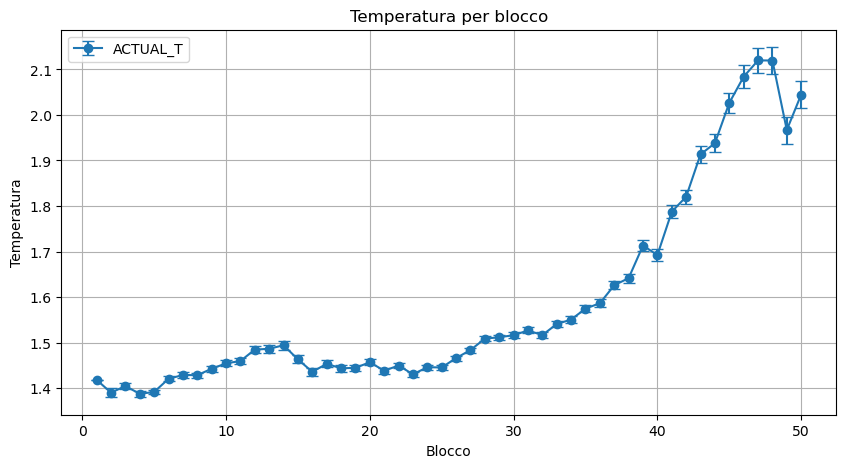

In [4]:
import numpy as np
import matplotlib.pyplot as plt

temp = np.genfromtxt("sim_num_es04.3/OUTPUT/temperature.dat", comments="#")

blocks = temp[:, 0]
actual_T = temp[:, 1]
T_ave = temp[:, 2]
err_T = temp[:, 3]

plt.figure(figsize=(10,5))
plt.errorbar(blocks, actual_T, yerr=err_T, fmt='o-', capsize=4, label="ACTUAL_T")

plt.xlabel("Blocco")
plt.ylabel("Temperatura")
plt.title("Temperatura per blocco")
plt.grid(True)
plt.legend()
plt.show()

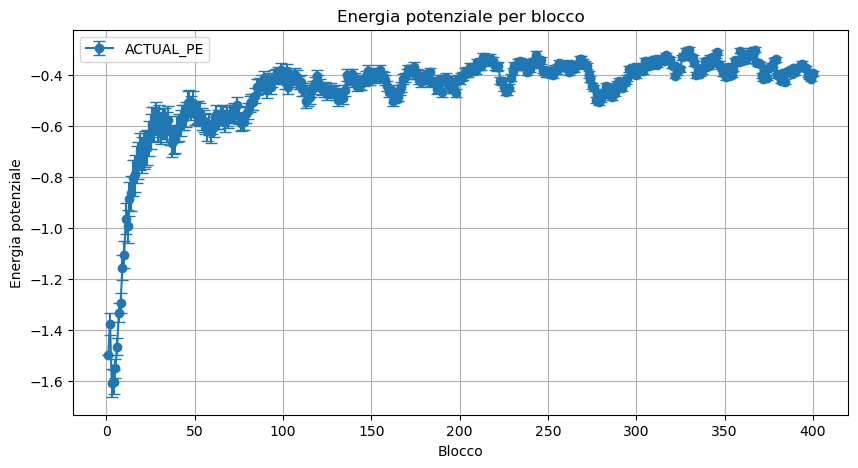

In [5]:
import numpy as np
import matplotlib.pyplot as plt

pe = np.genfromtxt("sim_num_es04.3/OUTPUT/potential_energy.dat", comments="#")

blocks = pe[:, 0]
actual_PE = pe[:, 1]
PE_ave = pe[:, 2]
err_PE = pe[:, 3]

plt.figure(figsize=(10,5))
plt.errorbar(blocks, actual_PE, yerr=err_PE, fmt='o-', capsize=4, label="ACTUAL_PE")

plt.xlabel("Blocco")
plt.ylabel("Energia potenziale")
plt.title("Energia potenziale per blocco")
plt.grid(True)
plt.legend()
plt.show()

## Commento
Si osserva come il sistema, durante la simulazione time reversed, ripercorre i propri passi, per ritornare nella configurazione iniziale a bassa entropia. Ciò è coerente con la simmetria per inversione temporale dell'algoritmo di Verlet.

Nelle simulazioni time reversed il numero di blocchi è inferiore poiché con numero di blocchi elevato, a causa dell'aumentare del numero di errori, il sistema non è più in grado di ripercorrere i suoi passi.